In [1]:
# Libraries
from sqlalchemy import create_engine, URL
import pandas as pd
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv

In [2]:
load_dotenv()

url = URL.create(
    drivername="postgresql+psycopg",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT")),
    database=os.getenv("DB_NAME")
)

engine = create_engine(url)

In [4]:
query = """
SELECT
    s.steam_appid AS app_id,
    g.title,
    g.release_date,
    g.launch_price,
    g.reviews_total,
    g.reviews_score_fancy,
    g.tags,
    s.month,
    s.avg_players,
    s.peak_players
FROM steam s

INNER JOIN games g
    ON s.steam_appid = g.app_id

INNER JOIN steam_summary ss
    ON s.steam_appid = ss.steam_appid

WHERE ss.months_observed >= 24

ORDER BY s.steam_appid, s.month;
"""

lifecycle = pd.read_sql(query, engine)
lifecycle

,app_id,title,release_date,launch_price,reviews_total,reviews_score_fancy,tags,month,avg_players,peak_players
0,10,Counter-Strike,2000-11-01,9.99,137421,0.97,"Action, FPS, Multiplayer, Shooter, Classic, Te...",2012-07-01,34139.20,53967
1,10,Counter-Strike,2000-11-01,9.99,137421,0.97,"Action, FPS, Multiplayer, Shooter, Classic, Te...",2012-08-01,33095.80,53685
2,10,Counter-Strike,2000-11-01,9.99,137421,0.97,"Action, FPS, Multiplayer, Shooter, Classic, Te...",2012-09-01,29432.56,55321
3,10,Counter-Strike,2000-11-01,9.99,137421,0.97,"Action, FPS, Multiplayer, Shooter, Classic, Te...",2012-10-01,28836.29,56053
4,10,Counter-Strike,2000-11-01,9.99,137421,0.97,"Action, FPS, Multiplayer, Shooter, Classic, Te...",2012-11-01,29669.97,56957
...,...,...,...,...,...,...,...,...,...,...
524541,802450,NAIRI: Tower of Shirin,2018-11-29,9.99,173,0.90,"Adventure, Indie, Cute, Singleplayer, Visual N...",2021-04-01,1.13,4
524542,802450,NAIRI: Tower of Shirin,2018-11-29,9.99,173,0.90,"Adventure, Indie, Cute, Singleplayer, Visual N...",2021-05-01,1.16,3
524543,802450,NAIRI: Tower of Shirin,2018-11-29,9.99,173,0.90,"Adventure, Indie, Cute, Singleplayer, Visual N...",2021-06-01,1.01,3
524544,802450,NAIRI: Tower of Shirin,2018-11-29,9.99,173,0.90,"Adventure, Indie, Cute, Singleplayer, Visual N...",2021-07-01,1.04,4


In [5]:
# Change month to lifecycle
lifecycle["month"] = pd.to_datetime(lifecycle["month"])

lifecycle["first_month"] = (
    lifecycle.groupby("app_id")["month"]
    .transform("min")
)

lifecycle["month_num"] = (
    (lifecycle["month"].dt.year - lifecycle["first_month"].dt.year) * 12
    + lifecycle["month"].dt.month
    - lifecycle["first_month"].dt.month
)

lifecycle[
    ["title", "month", "first_month", "month_num", "avg_players"]
].head(20)

,title,month,first_month,month_num,avg_players
0,Counter-Strike,2012-07-01,2012-07-01,0,34139.20
1,Counter-Strike,2012-08-01,2012-07-01,1,33095.80
2,Counter-Strike,2012-09-01,2012-07-01,2,29432.56
3,Counter-Strike,2012-10-01,2012-07-01,3,28836.29
4,Counter-Strike,2012-11-01,2012-07-01,4,29669.97
5,Counter-Strike,2012-12-01,2012-07-01,5,31996.07
6,Counter-Strike,2013-01-01,2012-07-01,6,34814.47
7,Counter-Strike,2013-02-01,2012-07-01,7,28378.42
8,Counter-Strike,2013-03-01,2012-07-01,8,24139.15
9,Counter-Strike,2013-04-01,2012-07-01,9,21204.46


In [6]:
# Normalize games
baseline = (
    lifecycle[lifecycle["month_num"].between(0, 2)]
    .groupby("app_id")["avg_players"]
    .mean()
    .rename("baseline_players")
)

lifecycle = lifecycle.merge(
    baseline,
    on="app_id"
)

lifecycle["relative_players"] = (
    lifecycle["avg_players"]
    / lifecycle["baseline_players"]
)

In [ ]:
# Compare the player base from first 3 months of the first year of its release to the last 3 months of the first/second year

# Year 1
relative_12m = (
    lifecycle[lifecycle["month_num"].between(9, 11)]
    .groupby("app_id")["relative_players"]
    .mean()
    .rename("relative_12m")
)

# Year 2
relative_24m = (
    lifecycle[lifecycle["month_num"].between(21, 23)]
    .groupby("app_id")["relative_players"]
    .mean()
    .rename("relative_24m")
)

game_lifecycle = (
    lifecycle.groupby("app_id")
    .agg(
        title=("title", "first"),
        launch_price=("launch_price", "first"),
        reviews_total=("reviews_total", "first"),
        review_score=("reviews_score_fancy", "first"),
        tags=("tags", "first"),
        baseline_players=("baseline_players", "first")
    )
    .join(relative_12m)
    .join(relative_24m)
    .reset_index()
)

game_lifecycle.head()

,app_id,title,launch_price,reviews_total,review_score,tags,baseline_players,relative_12m,relative_24m
0,10,Counter-Strike,9.99,137421,0.97,"Action, FPS, Multiplayer, Shooter, Classic, Te...",32222.520000,0.633616,0.560820
1,20,Team Fortress Classic,4.99,5475,0.85,"Action, FPS, Multiplayer, Classic, Hero Shoote...",91.676667,0.748027,0.702214
2,30,Day of Defeat,4.99,3692,0.87,"FPS, World War II, Multiplayer, Shooter, Actio...",308.633333,0.679015,0.624355
3,40,Deathmatch Classic,4.99,1923,0.80,"Action, FPS, Classic, Multiplayer, Shooter, Fi...",7.426667,0.583932,0.425494
4,50,Half-Life: Opposing Force,4.99,15498,0.95,"FPS, Action, Classic, Sci fi, Singleplayer, Sh...",63.696667,0.632268,0.774295


In [ ]:
game_lifecycle[
    ["baseline_players", "relative_12m", "relative_24m"]
].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])

# Need to fix infinite mean which is because of 0 baseline players games

c:\Users\mingj\miniforge3\envs\videogame\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\mingj\miniforge3\envs\videogame\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,baseline_players,relative_12m,relative_24m
count,5230.000000,5137.000000,5151.000000
mean,434.979546,inf,inf
std,3602.646712,NaN,NaN
min,0.000000,0.000000,0.002213
10%,0.156667,0.182226,0.127869
25%,0.856667,0.337785,0.283537
50%,6.603333,0.679310,0.660793
75%,50.375000,1.504705,1.803390
90%,337.856667,9.174118,15.618785
max,125086.890000,inf,inf


In [ ]:
for threshold in [0, 1, 5, 10, 25, 50]:
    count = (game_lifecycle["baseline_players"] >= threshold).sum()
    print(threshold, count)

# Choose 5 base line players since drop in players isn't significant

0 5230
1 3841
5 2799
10 2347
25 1714
50 1312


In [11]:
game_lifecycle_clean = game_lifecycle[
    game_lifecycle["baseline_players"] >= 5
].copy()

game_lifecycle_clean = game_lifecycle_clean.dropna(
    subset=["relative_12m", "relative_24m"]
)

game_lifecycle_clean[
    ["baseline_players", "relative_12m", "relative_24m"]
].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])

,baseline_players,relative_12m,relative_24m
count,2798.000000,2798.000000,2798.000000
mean,811.975225,1.722760,2.045832
std,4894.757103,29.278319,35.356922
min,5.003333,0.000971,0.002213
10%,7.645667,0.168018,0.121382
25%,14.092500,0.280820,0.233301
50%,42.203333,0.520334,0.480693
75%,204.817500,0.964262,1.027498
90%,949.569667,1.759091,2.160729
max,125086.890000,1493.657121,1778.878870


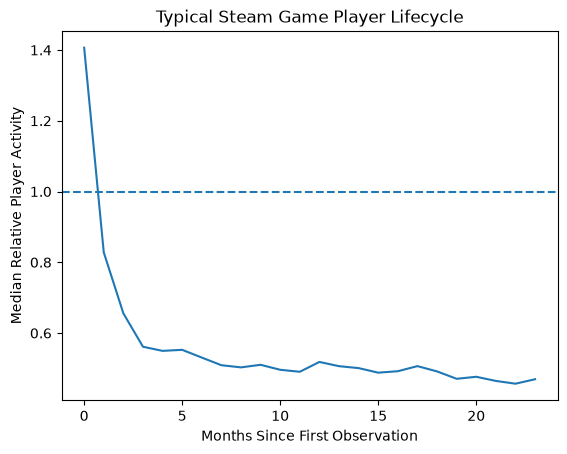

In [ ]:
# Keep games that survived baselien filter
valid_games = game_lifecycle_clean["app_id"]

lifecycle_clean = lifecycle[
    lifecycle["app_id"].isin(valid_games)
].copy()

# Look at first 2 years
first_24_months = lifecycle_clean[
    lifecycle_clean["month_num"].between(0, 23)
]

# Median relative player activity
typical_lifecycle = (
    first_24_months
    .groupby("month_num")["relative_players"]
    .median()
    .reset_index()
)

plt.plot(
    typical_lifecycle["month_num"],
    typical_lifecycle["relative_players"]
)

plt.xlabel("Months Since First Observation")
plt.ylabel("Median Relative Player Activity")
plt.title("Typical Steam Game Player Lifecycle")

plt.axhline(1, linestyle="--")

plt.show()

# Steam games experience their largest decline in player activity within the first few observed months. 
# After, median relative activity stabilizes at roughly half of the early-period baseline through the remainder of the first two years.